Librarys

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Sales Dataset.csv")
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8521 entries, 0 to 8520
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8521 non-null   object 
 1   Item_Weight                7058 non-null   float64
 2   Item_Fat_Content           8521 non-null   object 
 3   Item_Visibility            8521 non-null   float64
 4   Item_Type                  8521 non-null   object 
 5   Item_MRP                   8521 non-null   float64
 6   Outlet_Identifier          8521 non-null   object 
 7   Outlet_Establishment_Year  8521 non-null   int64  
 8   Outlet_Size                6111 non-null   object 
 9   Outlet_Location_Type       8521 non-null   object 
 10  Outlet_Type                8521 non-null   object 
 11  Item_Outlet_Sales          8521 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.0+ KB


(8521, 12)

Missing value

In [10]:

# Check missing values
print(df.isnull().sum())

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
date                            0
dtype: int64


Column,row

In [9]:
df['date'] = pd.to_datetime(df['Outlet_Establishment_Year'], format='%Y')

# Check datatype
print(df.dtypes)

Item_Identifier                      object
Item_Weight                         float64
Item_Fat_Content                     object
Item_Visibility                     float64
Item_Type                            object
Item_MRP                            float64
Outlet_Identifier                    object
Outlet_Establishment_Year             int64
Outlet_Size                          object
Outlet_Location_Type                 object
Outlet_Type                          object
Item_Outlet_Sales                   float64
date                         datetime64[ns]
dtype: object


Remove dupplicates

In [11]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check shape
print(df.shape)

(8521, 13)


Handle inconsistencies

In [12]:
# Remove extra spaces
df['Outlet_Location_Type'] = df['Outlet_Location_Type'].str.strip()

# Convert to lowercase
df['Outlet_Location_Type'] = df['Outlet_Location_Type'].str.lower()

Total Sales

In [13]:
# Calculate total sales
total_sales = df['Item_Outlet_Sales'].sum()

print("Total sales:", total_sales)

Total sales: 18588086.6992


Average Sales

In [14]:
# Calculate average sales
average_sales = df['Item_Outlet_Sales'].mean()

print("Average Sales:", average_sales)

Average Sales: 2181.444278746626


Maximum and Minimum Sales

In [15]:
# Maximum sales
max_sales = df['Item_Outlet_Sales'].max()

# Minimum sales
min_sales = df['Item_Outlet_Sales'].min()

print("Maximum Sales:", max_sales)
print("Minimum Sales:", min_sales)

Maximum Sales: 13086.9648
Minimum Sales: 33.29


Understand Data Distribution

In [16]:
# Summary statistics
print(df['Item_Outlet_Sales'].describe())

count     8521.000000
mean      2181.444279
std       1706.662438
min         33.290000
25%        833.581600
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


4. Sales Trend Analysis

Analyze sales over time

In [17]:
# Group sales by month
monthly_sales = df.groupby(df['date'].dt.month)['Item_Outlet_Sales'].sum()

print(monthly_sales)

date
1    1.858809e+07
Name: Item_Outlet_Sales, dtype: float64


Identify Seasonal Trends

In [18]:
# Extract month name
df['Month'] = df['date'].dt.month_name()

# Monthly sales trend
seasonal_sales = df.groupby('Month')['Item_Outlet_Sales'].sum()

print(seasonal_sales)

Month
January    1.858809e+07
Name: Item_Outlet_Sales, dtype: float64


Detect Peak Sales Periods

In [19]:
# Find highest sales day
peak_sales = df.groupby('date')['Item_Outlet_Sales'].sum()

print(peak_sales.idxmax())
print(peak_sales.max())

1985-01-01 00:00:00
3633620.145


5. Store/Product Analysis

Compare sales across stores

In [20]:
# Store-wise total sales
store_sales = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()

print(store_sales)

Outlet_Identifier
OUT010    1.883402e+05
OUT013    2.142664e+06
OUT017    2.167465e+06
OUT018    1.849977e+06
OUT019    1.796941e+05
OUT027    3.453926e+06
OUT035    2.266930e+06
OUT045    2.036725e+06
OUT046    2.118395e+06
OUT049    2.183970e+06
Name: Item_Outlet_Sales, dtype: float64


Identify Best-Selling Products

In [21]:
# Product-wise sales
product_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].sum()

# Top selling products
best_products = product_sales.sort_values(ascending=False)

print(best_products.head())

Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.730940e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Name: Item_Outlet_Sales, dtype: float64


Analyze Low-Performing Products

In [22]:
# Low-performing products
product_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].sum()
low_products = product_sales.sort_values()

print(low_products.head())

Item_Type
Seafood          148868.2194
Breakfast        232298.9516
Others           325517.6096
Starchy Foods    351401.2504
Hard Drinks      457793.4272
Name: Item_Outlet_Sales, dtype: float64


6. Time-Based Analysis

 Daily sales trends

In [23]:
# Daily sales analysis
daily_sales = df.groupby('date')['Item_Outlet_Sales'].sum()

print(daily_sales)

date
1985-01-01    3.633620e+06
1987-01-01    2.142664e+06
1997-01-01    2.118395e+06
1998-01-01    1.883402e+05
1999-01-01    2.183970e+06
2002-01-01    2.036725e+06
2004-01-01    2.266930e+06
2007-01-01    2.167465e+06
2009-01-01    1.849977e+06
Name: Item_Outlet_Sales, dtype: float64


Monthly Sales Trends

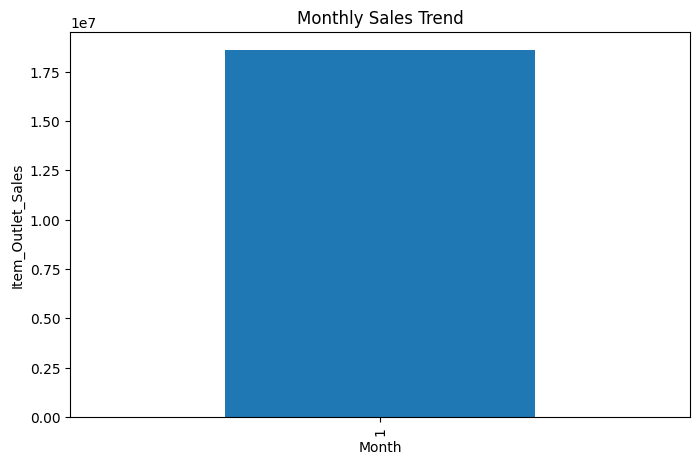

In [24]:
# Convert Date column
df['date'] = pd.to_datetime(df['date'])

# Create Month column
df['Month'] = df['date'].dt.month

# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Item_Outlet_Sales'].sum()

# Plot Graph
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Item_Outlet_Sales")

plt.show()

Yearly growth patterns

Year
1985    3.633620e+06
1987    2.142664e+06
1997    2.118395e+06
1998    1.883402e+05
1999    2.183970e+06
2002    2.036725e+06
2004    2.266930e+06
2007    2.167465e+06
2009    1.849977e+06
Name: Item_Outlet_Sales, dtype: float64


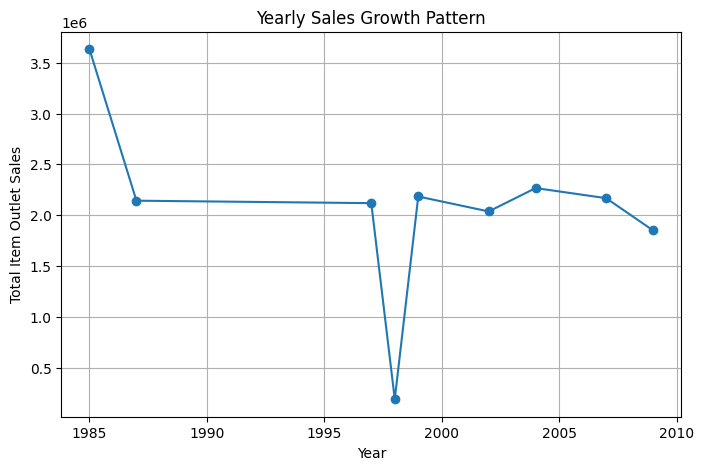

In [25]:
df.columns = df.columns.str.strip()

df['date'] = pd.to_datetime(df['date'])

df['Year'] = df['date'].dt.year

yearly_sales = df.groupby('Year')['Item_Outlet_Sales'].sum()

print(yearly_sales)

plt.figure(figsize=(8,5))

yearly_sales.plot(kind='line', marker='o')

plt.title("Yearly Sales Growth Pattern")
plt.xlabel("Year")
plt.ylabel("Total Item Outlet Sales")

plt.grid(True)

plt.show()

7. Relationship Analysis


• Date vs Sales


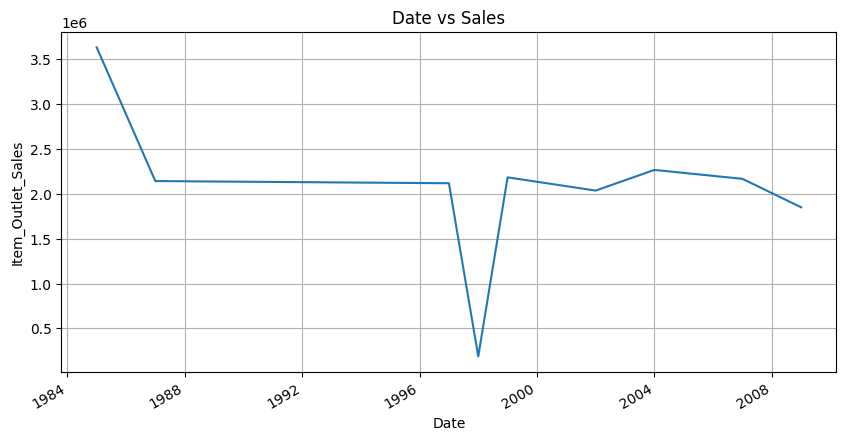

In [26]:
date_sales = df.groupby('date')['Item_Outlet_Sales'].sum()

plt.figure(figsize=(10,5))
date_sales.plot(kind='line')

plt.title("Date vs Sales")
plt.xlabel("Date")
plt.ylabel("Item_Outlet_Sales")

plt.grid(True)
plt.show()

• Store vs Sales


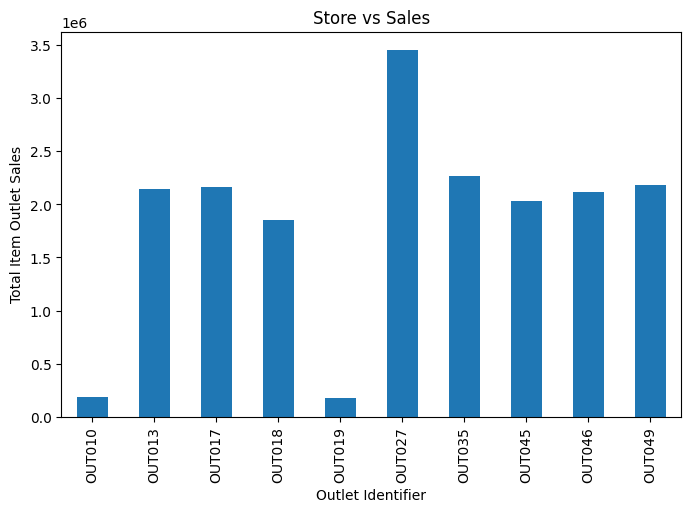

In [27]:
store_sales = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()

plt.figure(figsize=(8,5))
store_sales.plot(kind='bar')

plt.title("Store vs Sales")
plt.xlabel("Outlet Identifier")
plt.ylabel("Total Item Outlet Sales")

plt.show()

• Product vs Sales


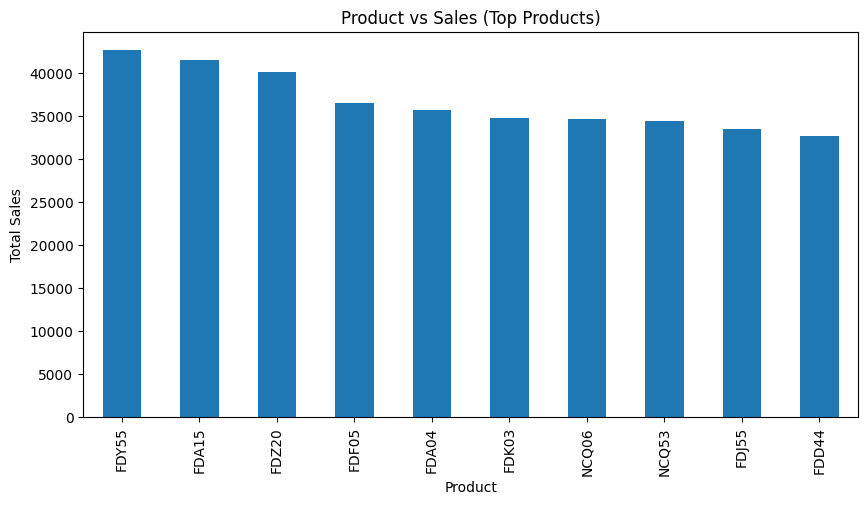

In [28]:
product_sales = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum()

# Top 10 Products
top_products = product_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title("Product vs Sales (Top Products)")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.show()

• Identify patterns affecting sales

In [29]:
best_store = store_sales.idxmax()
print("Best Performing Store:", best_store)

low_store = store_sales.idxmin()
print("Lowest Performing Store:", low_store)

best_product = product_sales.idxmax()
print("Best Selling Product:", best_product)

low_product = product_sales.idxmin()
print("Lowest Selling Product:", low_product)

Best Performing Store: OUT027
Lowest Performing Store: OUT019
Best Selling Product: FDY55
Lowest Selling Product: FDQ60


8. Data Visualization

• Line charts → Sales over time


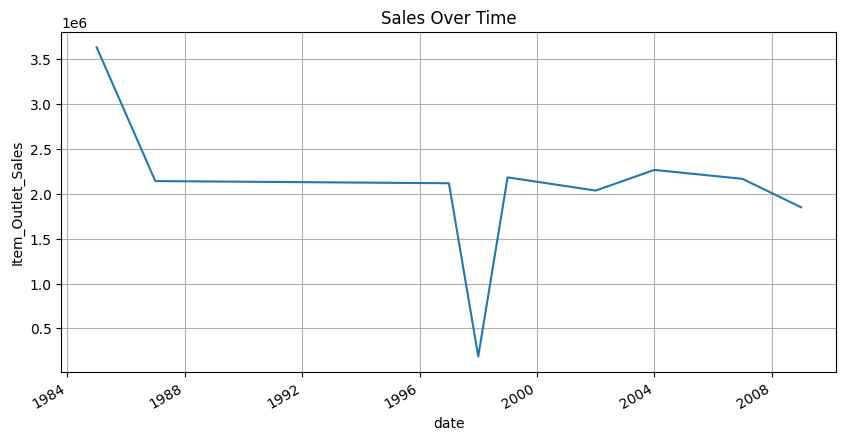

In [30]:
df['date'] = pd.to_datetime(df['date'])

sales_trend = df.groupby('date')['Item_Outlet_Sales'].sum()

# Plot Line Chart
plt.figure(figsize=(10,5))

sales_trend.plot(kind='line')

plt.title("Sales Over Time")
plt.xlabel("date")
plt.ylabel("Item_Outlet_Sales")

plt.grid(True)

plt.show()

• Bar charts → Store/Product comparison

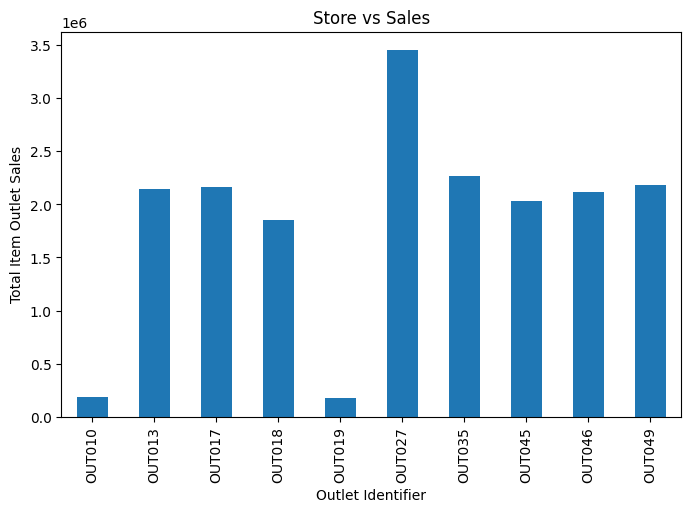

In [31]:
store_sales = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()

# Plot Bar Chart
plt.figure(figsize=(8,5))

store_sales.plot(kind='bar')

plt.title("Store vs Sales")
plt.xlabel("Outlet Identifier")
plt.ylabel("Total Item Outlet Sales")

plt.show()

• Histograms → Sales distribution

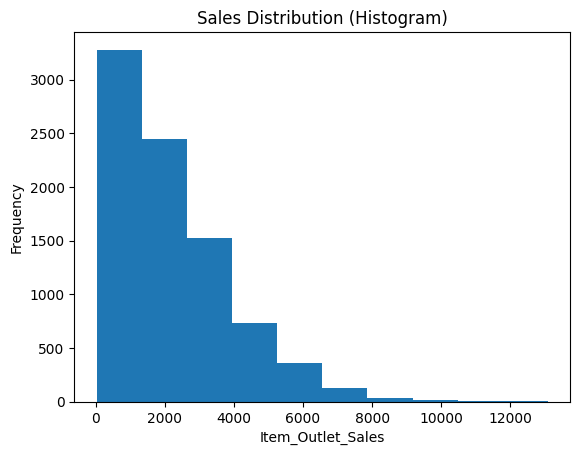

In [32]:
plt.figure()
plt.hist(df["Item_Outlet_Sales"], bins=10)
plt.title("Sales Distribution (Histogram)")
plt.xlabel("Item_Outlet_Sales")
plt.ylabel("Frequency")
plt.show()

• Box plots → Outlier detection

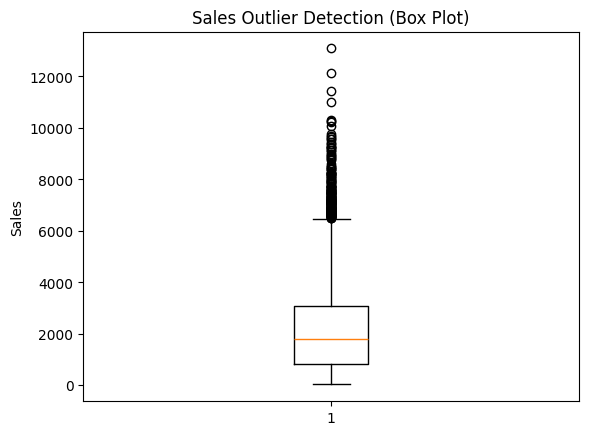

In [34]:
plt.figure()
plt.boxplot(df["Item_Outlet_Sales"])
plt.title("Sales Outlier Detection (Box Plot)")
plt.ylabel("Sales")
plt.show()

• Heatmaps → Correlation

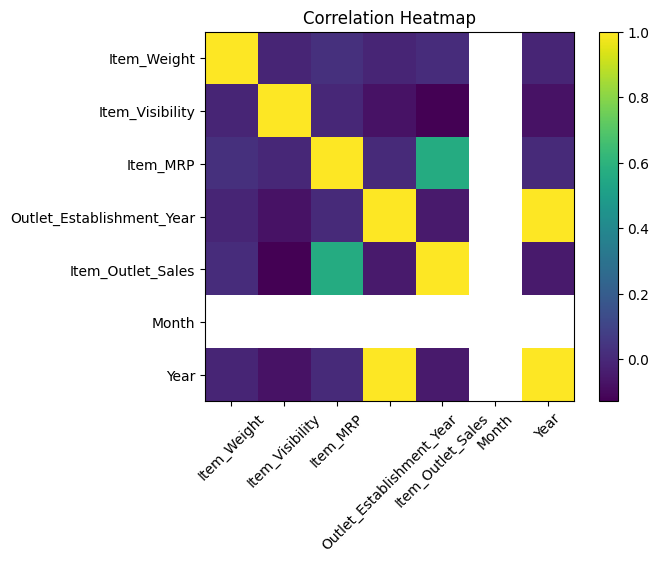

In [36]:
corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Succesfully Run")